# 多模态融合（高级策略）

实现了更进一步的融合策略：
- 个体基线校准
- 阶段感知的模态权重
- 动态阈值
- 上下文 bandit（RL 风格）的自适应权重

输出结果将保存到 `data/fusion/demo_output/`

In [29]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
# 修复 matplotlib 图表中文及负号无法正常显示的问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# 修复并稳健化根目录寻址逻辑
ROOT = Path.cwd()
if 'data' in ROOT.parts:
    # 如果当前工作目录在 data 或其子目录内部，直接截断回退到真实的项目根目录
    ROOT = Path(*ROOT.parts[:ROOT.parts.index('data')])
elif not (ROOT / 'data').exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data'
# 修改输出目录至 demo_output
OUT_DIR = DATA_DIR / 'fusion' / 'demo_output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

GAIT_PATH = DATA_DIR / 'gait' / 'example_gait_output.csv'
ICF_PATH = DATA_DIR / 'icf' / 'example_icf_output.csv'
SENSOR_PATH = DATA_DIR / 'sensor' / 'example_sensor_output.csv'

print('ROOT:', ROOT)
print('OUT_DIR:', OUT_DIR)

ROOT: C:\Users\12492\Desktop\Orthopedic-Recovery
OUT_DIR: C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output


## 数据加载与构建

尝试从各个模态的输出目录下读取 CSV 结果文件。如果文件不存在或样本过少，将自动生成模拟数据用于策略演示。

In [30]:
def _pick_numeric(df, fallback_name):
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        return pd.Series(np.zeros(len(df))), fallback_name
    return df[num_cols[0]].astype(float), num_cols[0]

def _safe_read(path):
    if path.exists():
        try:
            return pd.read_csv(path)
        except Exception:
            return None
    return None

def generate_synthetic(n_subjects=80, n_steps=30):
    rows = []
    for sid in range(n_subjects):
        baseline = np.random.uniform(0.35, 0.65)
        severity = np.random.choice([0, 1, 2])
        for t in range(n_steps):
            stage = 0 if t < n_steps * 0.33 else (1 if t < n_steps * 0.66 else 2)
            trend = t / max(1, n_steps - 1)
            
            gait = np.clip(baseline + 0.15 * trend - 0.08 * severity + np.random.normal(0, 0.06), 0, 1)
            icf = np.clip(1.0 - baseline + 0.05 * severity - 0.12 * trend + np.random.normal(0, 0.06), 0, 1)
            sensor = np.clip(0.5 * gait + 0.4 * (1 - icf) + np.random.normal(0, 0.08), 0, 1)

            latent = 0.45 * gait + 0.25 * (1 - icf) + 0.30 * sensor + 0.12 * trend - 0.10 * (severity / 2)
            y = int(latent > 0.55)

            rows.append({
                'subject_id': sid,
                'time_idx': t,
                'stage': stage,
                'severity': severity,
                'gait_score': gait,
                'icf_score': icf,
                'sensor_score': sensor,
                'target': y
            })
    return pd.DataFrame(rows)

def load_or_build_dataset():
    gait_df = _safe_read(GAIT_PATH)
    icf_df = _safe_read(ICF_PATH)
    sensor_df = _safe_read(SENSOR_PATH)

    if gait_df is None or icf_df is None or sensor_df is None:
        print('使用模拟数据（一个或多个 CSV 输入不可用）。')
        return generate_synthetic()

    n = min(len(gait_df), len(icf_df), len(sensor_df))
    if n < 40:
        print('使用模拟数据（CSV 行数不足）。')
        return generate_synthetic()

    gait_series, gait_col = _pick_numeric(gait_df.iloc[:n], 'gait_score')
    icf_series, icf_col = _pick_numeric(icf_df.iloc[:n], 'icf_score')
    sensor_series, sensor_col = _pick_numeric(sensor_df.iloc[:n], 'sensor_score')

    n_subjects = max(12, min(60, n // 8))
    steps = n // n_subjects
    rows = []
    idx = 0
    for sid in range(n_subjects):
        severity = np.random.choice([0, 1, 2])
        for t in range(steps):
            if idx >= n:
                break
            stage = 0 if t < steps * 0.33 else (1 if t < steps * 0.66 else 2)
            g = float(gait_series.iloc[idx])
            i = float(icf_series.iloc[idx])
            s = float(sensor_series.iloc[idx])
            g = 1.0 / (1.0 + math.exp(-g)) if abs(g) > 1 else np.clip(g, 0, 1)
            i = 1.0 / (1.0 + math.exp(-i)) if abs(i) > 1 else np.clip(i, 0, 1)
            s = 1.0 / (1.0 + math.exp(-s)) if abs(s) > 1 else np.clip(s, 0, 1)
            latent = 0.45 * g + 0.25 * (1 - i) + 0.30 * s + 0.06 * (t / max(1, steps - 1)) - 0.05 * (severity / 2)
            y = int(latent > 0.53)
            rows.append({
                'subject_id': sid,
                'time_idx': t,
                'stage': stage,
                'severity': severity,
                'gait_score': g,
                'icf_score': i,
                'sensor_score': s,
                'target': y
            })
            idx += 1

    if len(rows) < 150:
        print('使用模拟数据（构造样本过少）。')
        return generate_synthetic()

    print(f'已加载 CSV 数据列：gait={gait_col}, icf={icf_col}, sensor={sensor_col}')
    return pd.DataFrame(rows)

df = load_or_build_dataset()
print(df.head())
print('shape:', df.shape)

使用模拟数据（CSV 行数不足）。
   subject_id  time_idx  stage  severity  gait_score  icf_score  sensor_score  \
0           0         0      0         0    0.494987   0.500712      0.351384   
1           0         1      0         0    0.596034   0.527823      0.412582   
2           0         2      0         0    0.419593   0.504631      0.369335   
3           0         3      0         0    0.487729   0.539210      0.437620   
4           0         4      0         0    0.570794   0.613409      0.244905   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
shape: (2400, 8)


## 特征标准化与基线估计

In [31]:
feature_cols = ['gait_score', 'icf_score', 'sensor_score']

subject_ids = df['subject_id'].unique()
train_subj, test_subj = train_test_split(subject_ids, test_size=0.2, random_state=SEED)
train_subj, val_subj = train_test_split(train_subj, test_size=0.2, random_state=SEED)

train_df = df[df['subject_id'].isin(train_subj)].copy()
val_df = df[df['subject_id'].isin(val_subj)].copy()
test_df = df[df['subject_id'].isin(test_subj)].copy()

for d in (train_df, val_df, test_df):
    d['stage_raw'] = d['stage']
    d['severity_raw'] = d['severity']

scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

for d in (train_df, val_df, test_df):
    d['gait_prob'] = 1 / (1 + np.exp(-d['gait_score']))
    d['icf_prob'] = 1 / (1 + np.exp(-d['icf_score']))
    d['sensor_prob'] = 1 / (1 + np.exp(-d['sensor_score']))

early = train_df[train_df['time_idx'] <= train_df['time_idx'].quantile(0.25)]
baseline_map = early.groupby('subject_id')['target'].mean().to_dict()
global_baseline = float(train_df['target'].mean())

print('train/val/test:', len(train_df), len(val_df), len(test_df), 'global baseline:', round(global_baseline, 4))

train/val/test: 1530 390 480 global baseline: 0.3196


## 融合策略（阶段权重 + 动态阈值 + 上下文 bandit）

In [32]:
def stage_prior(stage_raw):
    if stage_raw <= 0:
        return np.array([0.30, 0.45, 0.25])
    if stage_raw == 1:
        return np.array([0.35, 0.35, 0.30])
    return np.array([0.45, 0.20, 0.35])

ACTIONS = [
    np.array([0.55, 0.25, 0.20]),
    np.array([0.45, 0.30, 0.25]),
    np.array([0.35, 0.35, 0.30]),
    np.array([0.25, 0.40, 0.35]),
    np.array([0.30, 0.20, 0.50]),
]

def context_key(row):
    sev_bin = int(np.clip(row['severity_raw'], 0, 2))
    stage_bin = int(np.clip(row['stage_raw'], 0, 2))
    return sev_bin, stage_bin

class ContextualBanditFusion:
    def __init__(self, n_actions, alpha=0.18, epsilon=0.18):
        self.n_actions = n_actions
        self.alpha = alpha
        self.epsilon = epsilon
        self.q = {}

    def _qvals(self, ctx):
        if ctx not in self.q:
            self.q[ctx] = np.zeros(self.n_actions, dtype=float)
        return self.q[ctx]

    def select_action(self, ctx):
        qvals = self._qvals(ctx)
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(qvals))

    def update(self, ctx, action, reward):
        qvals = self._qvals(ctx)
        qvals[action] += self.alpha * (reward - qvals[action])

    # 引入衰减机制，稳定后期训练过程
    def decay(self, decay_rate=0.92, min_alpha=0.01, min_epsilon=0.01):
        self.alpha = max(min_alpha, self.alpha * decay_rate)
        self.epsilon = max(min_epsilon, self.epsilon * decay_rate)

def fuse_prob(row, action_weights, dyn_threshold, baseline_strength=0.15):
    probs = np.array([row['gait_prob'], 1 - row['icf_prob'], row['sensor_prob']])
    sp = stage_prior(row['stage_raw'])
    w = 0.55 * action_weights + 0.45 * sp
    w = w / (np.sum(w) + 1e-8)
    base = baseline_map.get(int(row['subject_id']), global_baseline)
    fused = float(np.dot(w, probs))
    fused = (1 - baseline_strength) * fused + baseline_strength * base
    pred = int(fused >= dyn_threshold)
    return fused, pred, w

def dynamic_threshold(row, prev_reward, base=0.52):
    stage_adj = -0.04 if row['stage_raw'] == 0 else (0.00 if row['stage_raw'] == 1 else 0.03)
    sev_adj = 0.03 * max(0, row['severity_raw'])
    reward_adj = -0.04 * prev_reward
    thr = base + stage_adj + sev_adj + reward_adj
    return float(np.clip(thr, 0.35, 0.75))

## 训练与评估

In [33]:
def evaluate_static(df_eval):
    w = np.array([0.40, 0.30, 0.30])
    probs = (w[0] * df_eval['gait_prob'].values +
             w[1] * (1 - df_eval['icf_prob'].values) +
             w[2] * df_eval['sensor_prob'].values)
    y_true = df_eval['target'].values
    y_pred = (probs >= 0.5).astype(int)
    return y_true, probs, y_pred

def predict_bandit(bandit, df_eval):
    y_true, y_prob, y_pred = [], [], []
    prev_reward = 0.0

    for _, row in df_eval.iterrows():
        ctx = context_key(row)
        qvals = bandit._qvals(ctx)
        action = int(np.argmax(qvals))
        threshold = dynamic_threshold(row, prev_reward)
        fused, pred, _ = fuse_prob(row, ACTIONS[action], threshold)

        y = int(row['target'])
        reward = 1.0 if pred == y else -0.6
        reward += 0.3 * (1.0 - abs(fused - y))

        y_true.append(y)
        y_prob.append(fused)
        y_pred.append(pred)
        prev_reward = reward

    return np.array(y_true), np.array(y_prob), np.array(y_pred)

def train_bandit(train_df, val_df, episodes=60):
    # 适当提高初始学习率与探索率，结合衰减机制
    bandit = ContextualBanditFusion(n_actions=len(ACTIONS), alpha=0.2, epsilon=0.25)
    rewards_curve, val_f1_curve, weight_trace, threshold_trace = [], [], [], []
    train_rows = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    for _ in range(episodes):
        ep_rewards = []
        prev_reward = 0.0

        for _, row in train_rows.iterrows():
            ctx = context_key(row)
            action = bandit.select_action(ctx)
            threshold = dynamic_threshold(row, prev_reward)
            fused, pred, w = fuse_prob(row, ACTIONS[action], threshold)

            y = int(row['target'])
            reward = 1.0 if pred == y else -0.6
            reward += 0.3 * (1.0 - abs(fused - y))

            bandit.update(ctx, action, reward)
            ep_rewards.append(reward)
            prev_reward = reward
            weight_trace.append(w)
            threshold_trace.append(threshold)

        rewards_curve.append(float(np.mean(ep_rewards)))
        y_true_v, _, y_pred_v = predict_bandit(bandit, val_df)
        val_f1_curve.append(f1_score(y_true_v, y_pred_v, zero_division=0))
        
        # 每轮训练后应用衰减，收敛模型
        bandit.decay()

    return bandit, np.array(rewards_curve), np.array(val_f1_curve), np.array(weight_trace), np.array(threshold_trace)

bandit, rewards_curve, val_f1_curve, weight_trace, threshold_trace = train_bandit(train_df, val_df, episodes=60)

y_true_static, y_prob_static, y_pred_static = evaluate_static(test_df)
y_true_adv, y_prob_adv, y_pred_adv = predict_bandit(bandit, test_df)

def metric_dict(y_true, y_prob, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'auc': float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan
    }

metrics_df = pd.DataFrame([
    {'model': 'static_rule', **metric_dict(y_true_static, y_prob_static, y_pred_static)},
    {'model': 'advanced_bandit', **metric_dict(y_true_adv, y_prob_adv, y_pred_adv)}
])

metrics_df

,model,accuracy,f1,auc
0,static_rule,0.777083,0.792233,0.965055
1,advanced_bandit,0.831250,0.827292,0.964967


## 训练过程与性能可视化

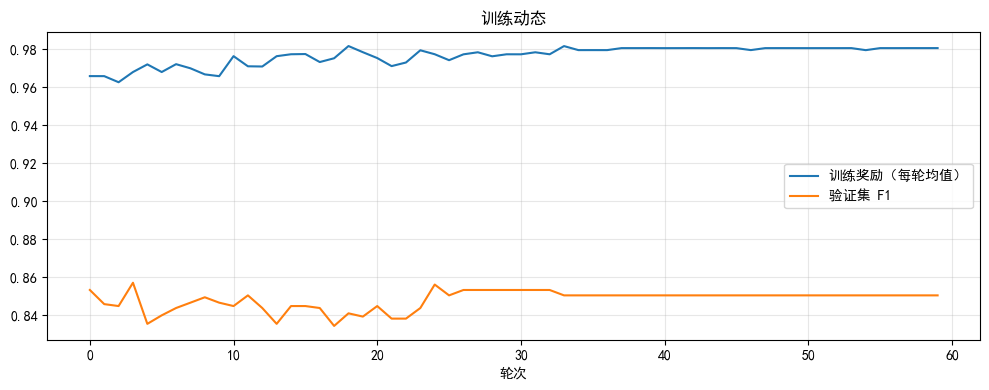

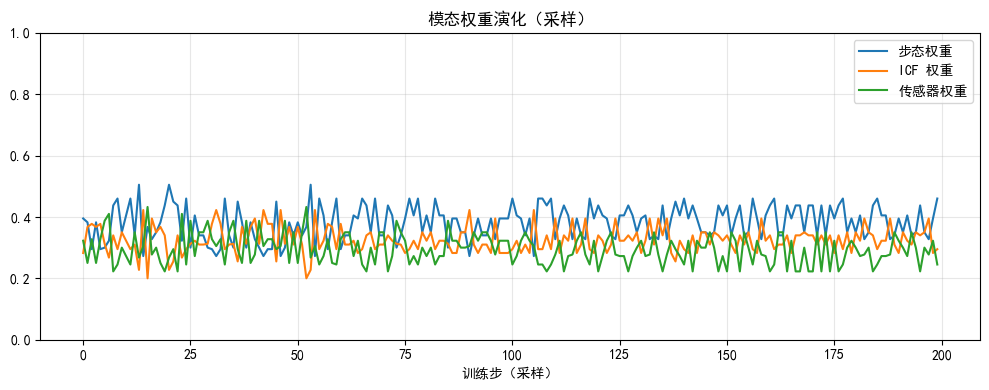

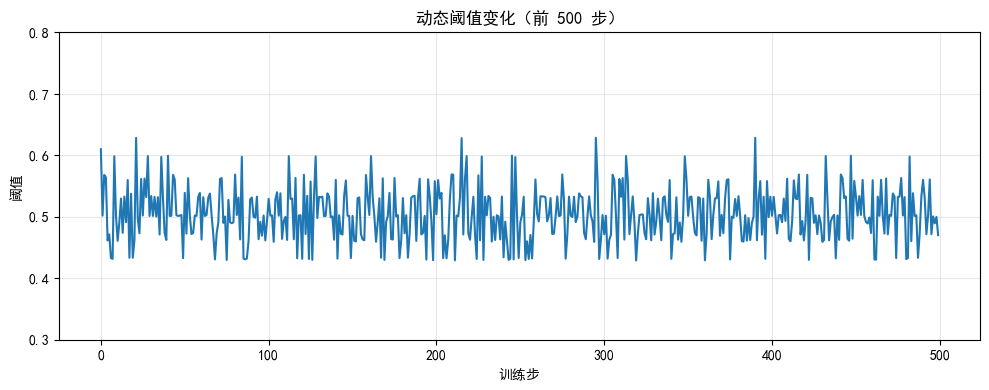

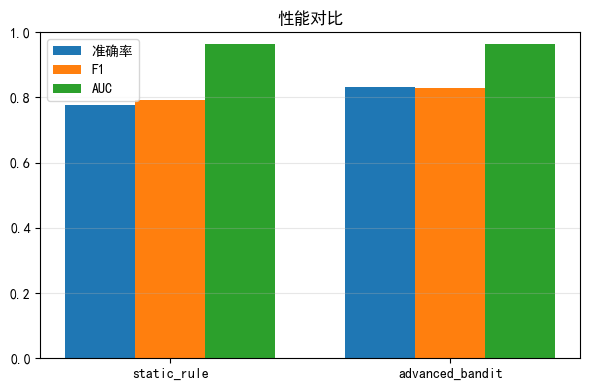

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(rewards_curve, label='训练奖励（每轮均值）')
plt.plot(val_f1_curve, label='验证集 F1')
plt.title('训练动态')
plt.xlabel('轮次')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'training_dynamics.png', dpi=150)
plt.show()

if len(weight_trace) > 10:
    sample_idx = np.linspace(0, len(weight_trace) - 1, num=min(200, len(weight_trace))).astype(int)
    wv = weight_trace[sample_idx]
    plt.figure(figsize=(10, 4))
    plt.plot(wv[:, 0], label='步态权重')
    plt.plot(wv[:, 1], label='ICF 权重')
    plt.plot(wv[:, 2], label='传感器权重')
    plt.title('模态权重演化（采样）')
    plt.xlabel('训练步（采样）')
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'weight_evolution.png', dpi=150)
    plt.show()

plt.figure(figsize=(10, 4))
plt.plot(threshold_trace[: min(500, len(threshold_trace))])
plt.title('动态阈值变化（前 500 步）')
plt.xlabel('训练步')
plt.ylabel('阈值')
plt.ylim(0.3, 0.8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'threshold_evolution.png', dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
x = np.arange(len(metrics_df))
bw = 0.25
plt.bar(x - bw, metrics_df['accuracy'], bw, label='准确率')
plt.bar(x, metrics_df['f1'], bw, label='F1')
plt.bar(x + bw, metrics_df['auc'].fillna(0), bw, label='AUC')
plt.xticks(x, metrics_df['model'])
plt.ylim(0, 1)
plt.title('性能对比')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'performance_comparison.png', dpi=150)
plt.show()

## 保存结果

将测试集的指标、预测概率、模态权重以及动态阈值的演化保存到指定输出目录。

In [35]:
metrics_path = OUT_DIR / 'advanced_metrics.csv'
weights_path = OUT_DIR / 'weight_trace.csv'
threshold_path = OUT_DIR / 'threshold_trace.csv'
pred_path = OUT_DIR / 'test_predictions.csv'

metrics_df.to_csv(metrics_path, index=False)
pd.DataFrame(weight_trace, columns=['w_gait', 'w_icf', 'w_sensor']).to_csv(weights_path, index=False)
pd.DataFrame({'threshold': threshold_trace}).to_csv(threshold_path, index=False)
pd.DataFrame({
    'y_true': y_true_adv,
    'y_prob_advanced': y_prob_adv,
    'y_pred_advanced': y_pred_adv,
    'y_prob_static': y_prob_static,
    'y_pred_static': y_pred_static
}).to_csv(pred_path, index=False)

print('Saved artifacts:')
for p in [metrics_path, weights_path, threshold_path, pred_path,
          OUT_DIR / 'training_dynamics.png',
          OUT_DIR / 'weight_evolution.png',
          OUT_DIR / 'threshold_evolution.png',
          OUT_DIR / 'performance_comparison.png']:
    print('-', p)

Saved artifacts:
- C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output\advanced_metrics.csv
- C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output\weight_trace.csv
- C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output\threshold_trace.csv
- C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output\test_predictions.csv
- C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output\training_dynamics.png
- C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output\weight_evolution.png
- C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output\threshold_evolution.png
- C:\Users\12492\Desktop\Orthopedic-Recovery\data\fusion\demo_output\performance_comparison.png
